exp 9

LINEAR REGRESSION
MSE: 211.2000000000001
R2 Score: 0.9574468085106382

POLYNOMIAL REGRESSION
MSE: 3.177866455689539e-23
R2 Score: 1.0

House Size: 1700 sq.ft
Linear Prediction: 116.0 Lakhs
Polynomial Prediction: 99.5 Lakhs


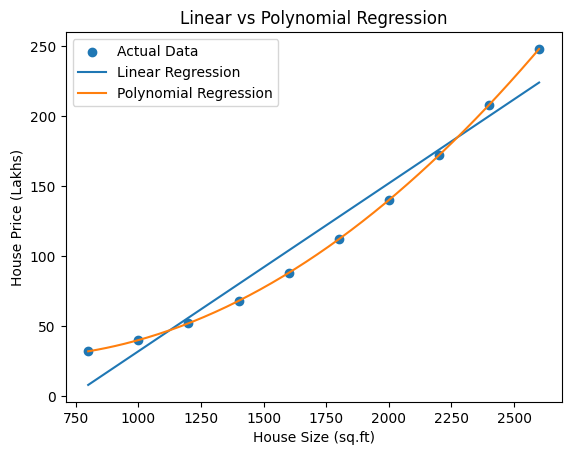

In [6]:
# EXPERIMENT 9
# Compare Linear and Polynomial Regression

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# House Size vs House Price
X = np.array([
    [800],
    [1000],
    [1200],
    [1400],
    [1600],
    [1800],
    [2000],
    [2200],
    [2400],
    [2600]
])

y = np.array([32, 40, 52, 68, 88, 112, 140, 172, 208, 248])

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X, y)

linear_pred = linear_model.predict(X)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

poly_pred = poly_model.predict(X_poly)

# Evaluation
print("LINEAR REGRESSION")
print("MSE:", mean_squared_error(y, linear_pred))
print("R2 Score:", r2_score(y, linear_pred))

print("\nPOLYNOMIAL REGRESSION")
print("MSE:", mean_squared_error(y, poly_pred))
print("R2 Score:", r2_score(y, poly_pred))

# New sample
new_sample = np.array([[1700]])

linear_prediction = linear_model.predict(new_sample)

poly_prediction = poly_model.predict(
    poly.transform(new_sample)
)

print("\nHouse Size:", 1700, "sq.ft")
print("Linear Prediction:",
      round(linear_prediction[0], 2), "Lakhs")

print("Polynomial Prediction:",
      round(poly_prediction[0], 2), "Lakhs")

# Graph
X_curve = np.linspace(800, 2600, 200).reshape(-1, 1)

linear_curve = linear_model.predict(X_curve)

poly_curve = poly_model.predict(
    poly.transform(X_curve)
)

plt.scatter(X, y, label="Actual Data")
plt.plot(X_curve, linear_curve, label="Linear Regression")
plt.plot(X_curve, poly_curve, label="Polynomial Regression")

plt.xlabel("House Size (sq.ft)")
plt.ylabel("House Price (Lakhs)")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()